In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

STEP 1 — Dataset Overview
Shape        : (50, 13)
Columns      : ['Symbol', 'Open', 'High', 'Low', 'LTP', 'Chng', '% Chng', 'Volume (lacs)', 'Turnover (crs.)', '52w H', '52w L', '365 d % chng', '30 d % chng']

First 5 rows:
       Symbol       Open       High        Low        LTP    Chng  % Chng  Volume (lacs) Turnover (crs.)      52w H     52w L  365 d % chng  30 d % chng
0  ADANIPORTS        750        766     713.25        715  -47.45   -6.22          72.20          532.63        901     384.4         79.22        -4.65
1  ASIANPAINT   3,101.00   3,167.35   3,091.00   3,138.00   -6.25   -0.20          10.29          322.53   3,505.00  2,117.15         45.66         5.66
2    AXISBANK        669      674.9     660.45        661  -18.90   -2.78         102.53             684      866.9     568.4         10.19       -21.49
3  BAJAJ-AUTO   3,370.00   3,383.50   3,320.00   3,335.00  -56.70   -1.67           3.42          114.59   4,361.40  3,041.00          9.30       -12.05
4  BAJAJFIN

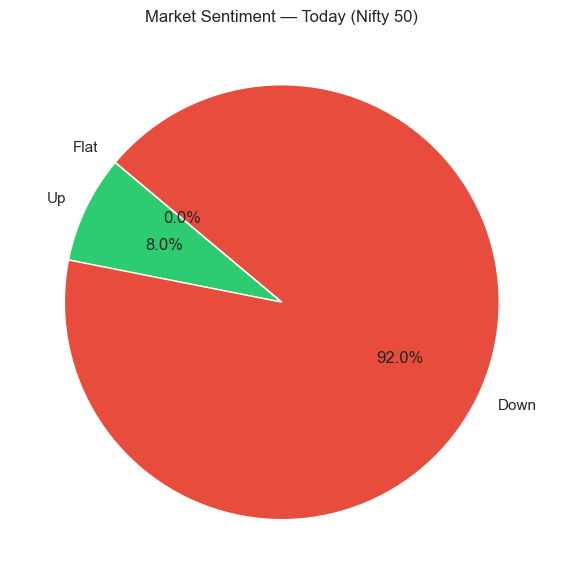

Chart saved: plot1_market_sentiment.png

STEP 4 — Top Gainers & Losers Today
Top 5 Gainers:
   Symbol  % Chng
    CIPLA    7.23
  DRREDDY    3.45
 DIVISLAB    2.92
NESTLEIND    0.38
      TCS   -0.19

Top 5 Losers:
    Symbol  % Chng
INDUSINDBK   -6.19
ADANIPORTS   -6.22
  HINDALCO   -6.57
TATAMOTORS   -6.77
  JSWSTEEL   -7.48


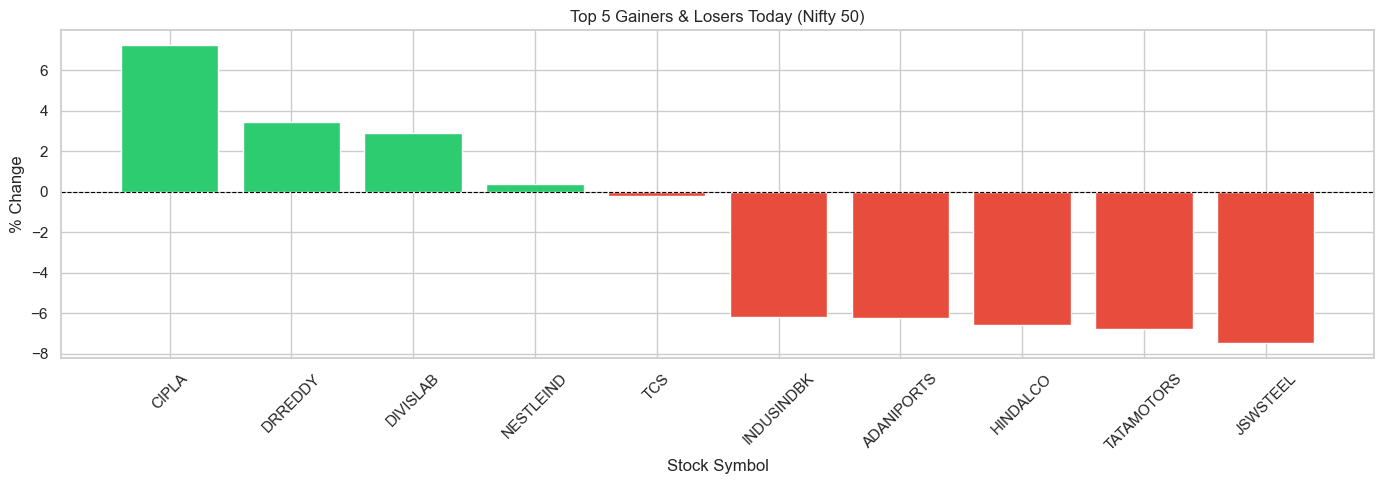

Chart saved: plot2_gainers_losers.png

STEP 5 — 1-Year Returns
Best  1-year : TATAMOTORS → 167.95 %
Worst 1-year : HEROMOTOCO → -16.02 %


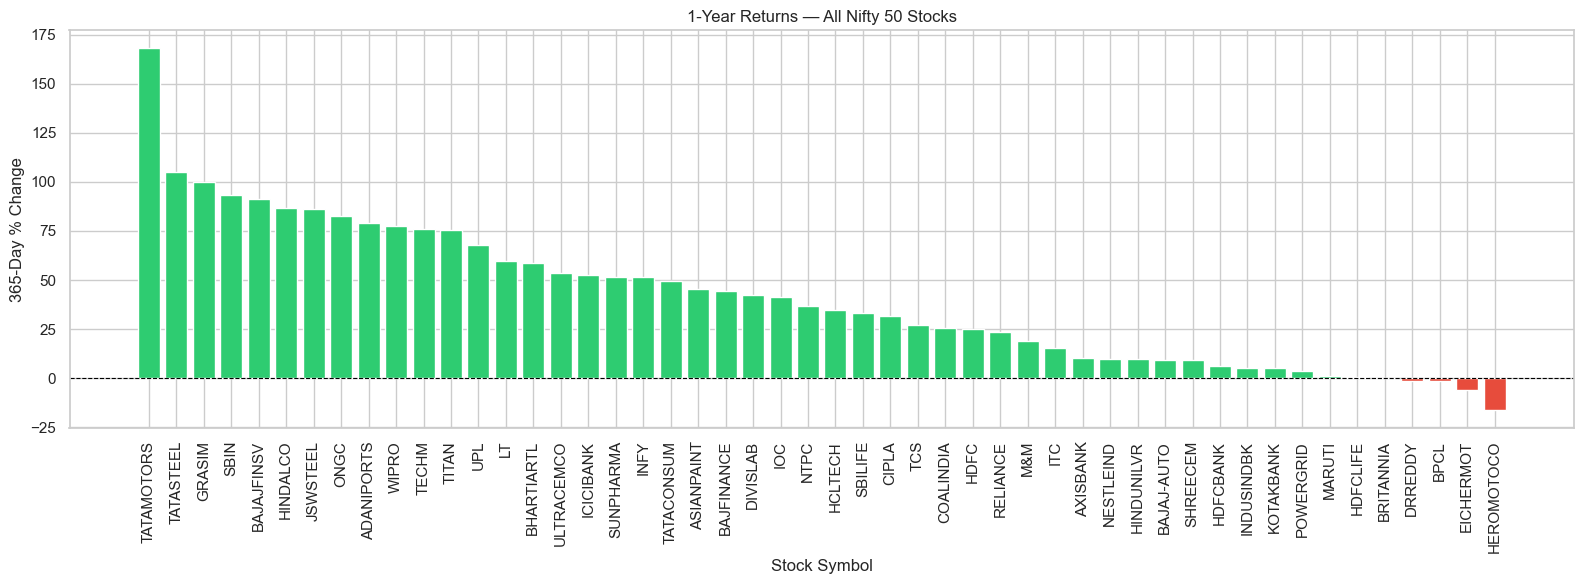

Chart saved: plot3_yearly_returns.png

STEP 6 — Volume Analysis
Top 10 by Volume:
    Symbol  Volume (lacs) Turnover (crs.)
TATAMOTORS         517.88        2,430.36
       ITC         270.27          610.54
      SBIN         263.06        1,249.55
      ONGC         231.36          344.33
 ICICIBANK         189.88        1,385.86
  HINDALCO         148.26          631.93
     CIPLA         144.59        1,380.90
      NTPC         133.24          173.94
 COALINDIA         118.30           185.5
BHARTIARTL         111.43          830.06


C:\Users\harsh\AppData\Local\Temp\ipykernel_13048\1350136431.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Symbol', y='Volume (lacs)', data=top_vol, palette='Blues_d')


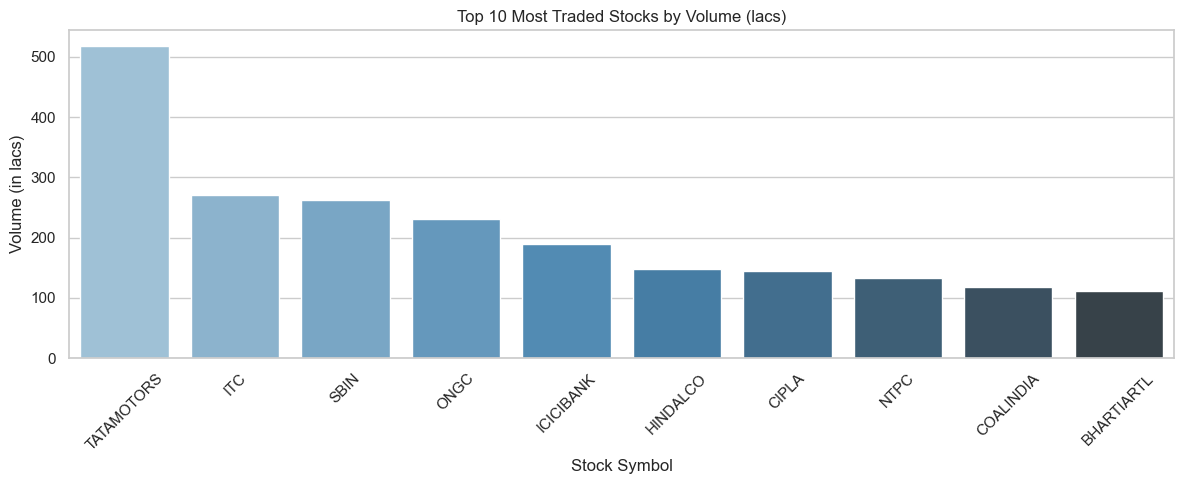

Chart saved: plot4_volume.png

STEP 7 — Distribution of Daily Returns
Average % change today : -2.93%
Std deviation          : 2.68%
Min                    : -7.48%
Max                    : 7.23%


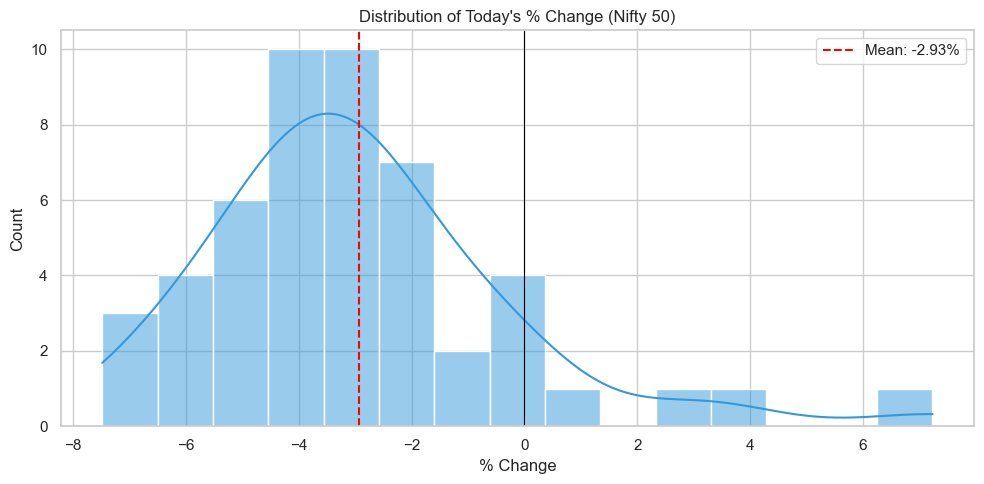

Chart saved: plot5_distribution.png

STEP 8 — Correlation Heatmap
Correlation Matrix:
                 % Chng  Volume (lacs)  Turnover (crs.)  365 d % chng  30 d % chng  Day_Range  52w_Range_pct
% Chng             1.00          -0.27            -0.10         -0.39         0.56       0.14          -0.49
Volume (lacs)     -0.27           1.00             0.62          0.49        -0.25      -0.34           0.54
Turnover (crs.)   -0.10           0.62             1.00          0.36        -0.21      -0.08           0.37
365 d % chng      -0.39           0.49             0.36          1.00        -0.08      -0.11           0.95
30 d % chng        0.56          -0.25            -0.21         -0.08         1.00       0.12          -0.26
Day_Range          0.14          -0.34            -0.08         -0.11         0.12       1.00          -0.11
52w_Range_pct     -0.49           0.54             0.37          0.95        -0.26      -0.11           1.00


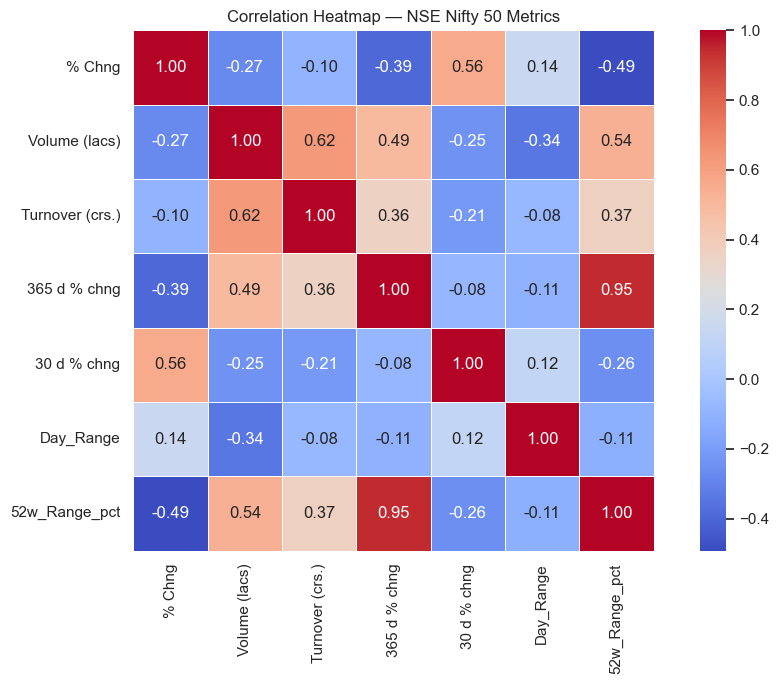

Chart saved: plot6_heatmap.png

STEP 9 — 30-Day vs 365-Day Returns


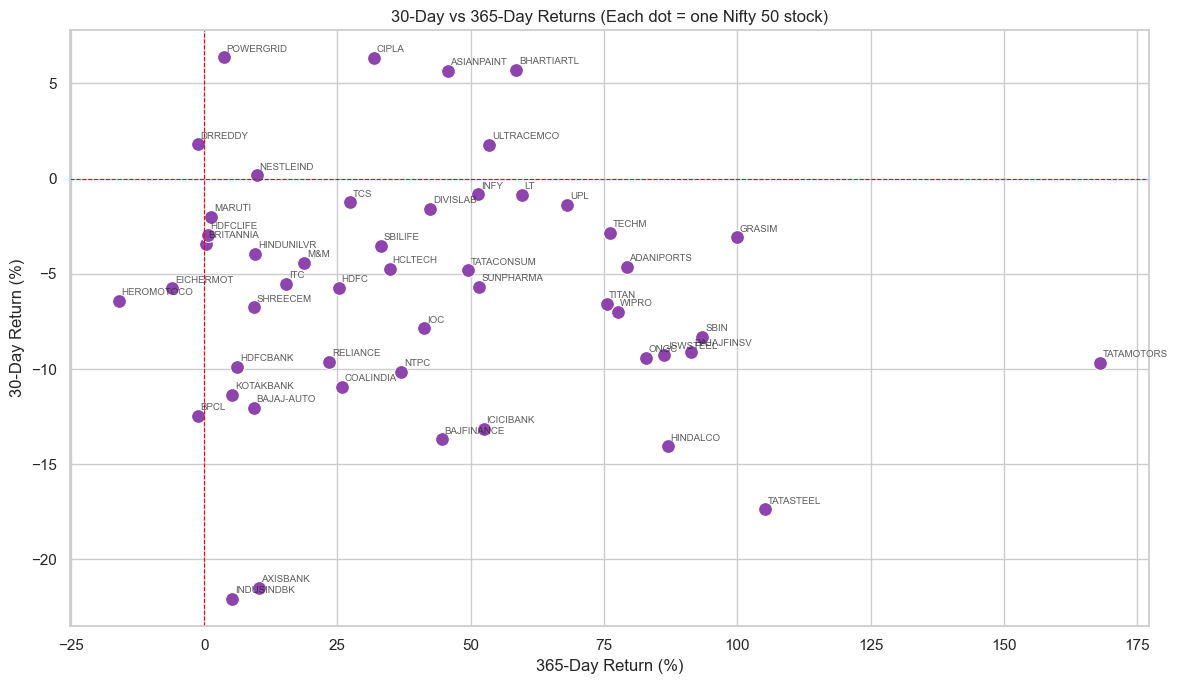

Chart saved: plot7_scatter.png

STEP 10 — Key Findings Summary
1. Market Sentiment  : 4 stocks UP, 46 stocks DOWN today
2. Top Gainer Today  : CIPLA  (+7.23%)
3. Top Loser Today   : JSWSTEEL (-7.48%)
4. Best 1-Year Stock : TATAMOTORS  (+167.95%)
5. Worst 1-Year Stock: HEROMOTOCO (-16.02%)
6. Most Traded Stock : TATAMOTORS  (Volume: 517.88 lacs)
7. Avg Return Today  : -2.93%

All charts saved as PNG files in the same folder.
EDA Complete!


In [ ]:
#analyzing the data and create visualizations to understand the market trends and stock performance. 
# The code will be structured in a step-by-step manner, covering data loading, cleaning, analysis, and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

#  STEP 1 : Load Data 
df = pd.read_csv('NSE_DATA.csv')
print("=" * 50)
print("STEP 1 — Dataset Overview")
print("=" * 50)
print("Shape        :", df.shape)
print("Columns      :", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head().to_string())
print("\nMissing values:")
print(df.isnull().sum())

#STEP 2 : Clean Data 
print("\n" + "=" * 50)
print("STEP 2 — Cleaning Data")
print("=" * 50)

cols_to_clean = ['Open', 'High', 'Low', 'LTP', '52w H', '52w L']
for col in cols_to_clean:
    df[col] = df[col].astype(str).str.replace(',', '').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# New calculated columns
df['Day_Range']     = df['High'] - df['Low']
df['52w_Range_pct'] = ((df['52w H'] - df['52w L']) / df['52w L']) * 100

print("Cleaned columns:", cols_to_clean)
print("New columns added: Day_Range, 52w_Range_pct")
print(df[['Symbol', 'Day_Range', '52w_Range_pct']].head().to_string())

 #STEP 3 : Market Sentiment 
print("\n" + "=" * 50)
print("STEP 3 — Market Sentiment")
print("=" * 50)

up   = (df['% Chng'] > 0).sum()
down = (df['% Chng'] < 0).sum()
flat = (df['% Chng'] == 0).sum()

print(f"Stocks UP    : {up}")
print(f"Stocks DOWN  : {down}")
print(f"Stocks FLAT  : {flat}")

plt.figure(figsize=(6, 6))
plt.pie([up, down, flat],
        labels=['Up', 'Down', 'Flat'],
        colors=['#2ecc71', '#e74c3c', '#95a5a6'],
        autopct='%1.1f%%', startangle=140)
plt.title('Market Sentiment — Today (Nifty 50)')
plt.tight_layout()
plt.savefig('plot1_market_sentiment.png', dpi=150)
plt.show()
print("Chart saved: plot1_market_sentiment.png")

#STEP 4 : Top Gainers & Losers Today
print("\n" + "=" * 50)
print("STEP 4 — Top Gainers & Losers Today")
print("=" * 50)

df_sorted = df.sort_values('% Chng', ascending=False)
top5      = df_sorted.head(5)
bottom5   = df_sorted.tail(5)

print("Top 5 Gainers:")
print(top5[['Symbol', '% Chng']].to_string(index=False))
print("\nTop 5 Losers:")
print(bottom5[['Symbol', '% Chng']].to_string(index=False))

combined = pd.concat([top5, bottom5])
colors   = ['#2ecc71' if x > 0 else '#e74c3c' for x in combined['% Chng']]

plt.figure(figsize=(14, 5))
plt.bar(combined['Symbol'], combined['% Chng'], color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top 5 Gainers & Losers Today (Nifty 50)')
plt.xlabel('Stock Symbol')
plt.ylabel('% Change')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot2_gainers_losers.png', dpi=150)
plt.show()
print("Chart saved: plot2_gainers_losers.png")

#STEP 5 : 365-Day Returns
print("\n" + "=" * 50)
print("STEP 5 — 1-Year Returns")
print("=" * 50)

df_yearly = df.sort_values('365 d % chng', ascending=False)
colors_yr = ['#2ecc71' if x > 0 else '#e74c3c' for x in df_yearly['365 d % chng']]

print("Best  1-year :", df_yearly.iloc[0]['Symbol'],  "→", df_yearly.iloc[0]['365 d % chng'], "%")
print("Worst 1-year :", df_yearly.iloc[-1]['Symbol'], "→", df_yearly.iloc[-1]['365 d % chng'], "%")

plt.figure(figsize=(16, 6))
plt.bar(df_yearly['Symbol'], df_yearly['365 d % chng'], color=colors_yr, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('1-Year Returns — All Nifty 50 Stocks')
plt.xlabel('Stock Symbol')
plt.ylabel('365-Day % Change')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('plot3_yearly_returns.png', dpi=150)
plt.show()
print("Chart saved: plot3_yearly_returns.png")

#  STEP 6 : Volume Analysis
print("\n" + "=" * 50)
print("STEP 6 — Volume Analysis")
print("=" * 50)

top_vol = df.sort_values('Volume (lacs)', ascending=False).head(10)
print("Top 10 by Volume:")
print(top_vol[['Symbol', 'Volume (lacs)', 'Turnover (crs.)']].to_string(index=False))

plt.figure(figsize=(12, 5))
sns.barplot(x='Symbol', y='Volume (lacs)', data=top_vol, palette='Blues_d')
plt.title('Top 10 Most Traded Stocks by Volume (lacs)')
plt.xlabel('Stock Symbol')
plt.ylabel('Volume (in lacs)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot4_volume.png', dpi=150)
plt.show()
print("Chart saved: plot4_volume.png")

# STEP 7 : Distribution of Daily Returns
print("\n" + "=" * 50)
print("STEP 7 — Distribution of Daily Returns")
print("=" * 50)

print(f"Average % change today : {df['% Chng'].mean():.2f}%")
print(f"Std deviation          : {df['% Chng'].std():.2f}%")
print(f"Min                    : {df['% Chng'].min():.2f}%")
print(f"Max                    : {df['% Chng'].max():.2f}%")

plt.figure(figsize=(10, 5))
sns.histplot(df['% Chng'], bins=15, kde=True, color='#3498db')
plt.axvline(df['% Chng'].mean(), color='red', linestyle='--',
            label=f"Mean: {df['% Chng'].mean():.2f}%")
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.title("Distribution of Today's % Change (Nifty 50)")
plt.xlabel('% Change')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('plot5_distribution.png', dpi=150)
plt.show()
print("Chart saved: plot5_distribution.png")

#  STEP 8 : Correlation Heatmap 
print("\n" + "=" * 50)
print("STEP 8 — Correlation Heatmap")
print("=" * 50)

numeric_cols = ['% Chng', 'Volume (lacs)', 'Turnover (crs.)',
                '365 d % chng', '30 d % chng', 'Day_Range', '52w_Range_pct']

# Force convert all columns to numeric — this fixes the ValueError
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')

corr = df[numeric_cols].corr()

print("Correlation Matrix:")
print(corr.round(2).to_string())

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — NSE Nifty 50 Metrics')
plt.tight_layout()
plt.savefig('plot6_heatmap.png', dpi=150)
plt.show()
print("Chart saved: plot6_heatmap.png")

#  STEP 9 : 30-Day vs 365-Day Scatter 
print("\n" + "=" * 50)
print("STEP 9 — 30-Day vs 365-Day Returns")
print("=" * 50)

plt.figure(figsize=(12, 7))
sns.scatterplot(x='365 d % chng', y='30 d % chng', data=df, s=100, color='#8e44ad')

for _, row in df.iterrows():
    plt.text(row['365 d % chng'] + 0.5, row['30 d % chng'] + 0.3,
             row['Symbol'], fontsize=7, alpha=0.75)

plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.title('30-Day vs 365-Day Returns (Each dot = one Nifty 50 stock)')
plt.xlabel('365-Day Return (%)')
plt.ylabel('30-Day Return (%)')
plt.tight_layout()
plt.savefig('plot7_scatter.png', dpi=150)
plt.show()
print("Chart saved: plot7_scatter.png")

#  STEP 10 : Summary 
print("\n" + "=" * 50)
print("STEP 10 — Key Findings Summary")
print("=" * 50)

best_today   = df.loc[df['% Chng'].idxmax()]
worst_today  = df.loc[df['% Chng'].idxmin()]
best_yearly  = df.loc[df['365 d % chng'].idxmax()]
worst_yearly = df.loc[df['365 d % chng'].idxmin()]
most_volume  = df.loc[df['Volume (lacs)'].idxmax()]

print(f"1. Market Sentiment  : {up} stocks UP, {down} stocks DOWN today")
print(f"2. Top Gainer Today  : {best_today['Symbol']}  ({best_today['% Chng']:+.2f}%)")
print(f"3. Top Loser Today   : {worst_today['Symbol']} ({worst_today['% Chng']:+.2f}%)")
print(f"4. Best 1-Year Stock : {best_yearly['Symbol']}  ({best_yearly['365 d % chng']:+.2f}%)")
print(f"5. Worst 1-Year Stock: {worst_yearly['Symbol']} ({worst_yearly['365 d % chng']:+.2f}%)")
print(f"6. Most Traded Stock : {most_volume['Symbol']}  (Volume: {most_volume['Volume (lacs)']} lacs)")
print(f"7. Avg Return Today  : {df['% Chng'].mean():.2f}%")
print("\nAll charts saved as PNG files in the same folder.")
print("EDA Complete!")